<a href="https://colab.research.google.com/github/Arpmee027/Future_Sales_Prediction_and_EDA/blob/main/Predicting_Future_Sales_with_ligthgbm_and_xgboost_FINAL_NEW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading dataset

Loading the data from the "Weekly_Shipment_Data" sheet in the "Processed_Online_Retail" Excel file into a pandas DataFrame.


In [2]:
import pandas as pd

df_weekly_sales = pd.read_excel('/content/drive/MyDrive/Predicting_Future_Sales_Project./Processed_Online_Retail_2.xlsx', sheet_name='Weekly_Shipment_Data')
display(df_weekly_sales.head())

,WeekStartDate,WeeklyShipments,StockCode
0,2010-11-29,986,85123A
1,2010-12-06,1045,85123A
2,2010-12-13,1524,85123A
3,2010-12-20,197,85123A
4,2010-12-27,0,85123A


## Feature engineering

Creating relevant features for time series forecasting.


In [3]:
df_weekly_sales['WeekStartDate'] = pd.to_datetime(df_weekly_sales['WeekStartDate'])
df_weekly_sales['year'] = df_weekly_sales['WeekStartDate'].dt.year
df_weekly_sales['month'] = df_weekly_sales['WeekStartDate'].dt.month
df_weekly_sales['dayofweek'] = df_weekly_sales['WeekStartDate'].dt.dayofweek
df_weekly_sales['weekofyear'] = df_weekly_sales['WeekStartDate'].dt.isocalendar().week

min_date = df_weekly_sales['WeekStartDate'].min()
df_weekly_sales['elapsed_weeks'] = (df_weekly_sales['WeekStartDate'] - min_date).dt.days // 7

df_weekly_sales_cleaned = df_weekly_sales.sort_values(by=['StockCode', 'WeekStartDate'])

for lag in [1, 4, 12]:
    df_weekly_sales_cleaned[f'lag_{lag}_weeks'] = df_weekly_sales_cleaned.groupby('StockCode')['WeeklyShipments'].shift(lag)

for window in [4, 12]:
    df_weekly_sales_cleaned[f'rolling_mean_{window}_weeks'] = df_weekly_sales_cleaned.groupby('StockCode')['WeeklyShipments'].rolling(window=window).mean().reset_index(level=0, drop=True)
    df_weekly_sales_cleaned[f'rolling_sum_{window}_weeks'] = df_weekly_sales_cleaned.groupby('StockCode')['WeeklyShipments'].rolling(window=window).sum().reset_index(level=0, drop=True)

df_weekly_sales_cleaned.fillna(0, inplace=True)

display(df_weekly_sales_cleaned.head())

,WeekStartDate,WeeklyShipments,StockCode,year,month,dayofweek,weekofyear,elapsed_weeks,lag_1_weeks,lag_4_weeks,lag_12_weeks,rolling_mean_4_weeks,rolling_sum_4_weeks,rolling_mean_12_weeks,rolling_sum_12_weeks
1674,2010-11-29,70,10002,2010,11,0,48,0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
1675,2010-12-06,138,10002,2010,12,0,49,1,70.0,0.0,0.0,0.00,0.0,0.0,0.0
1676,2010-12-13,41,10002,2010,12,0,50,2,138.0,0.0,0.0,0.00,0.0,0.0,0.0
1677,2010-12-20,2,10002,2010,12,0,51,3,41.0,0.0,0.0,62.75,251.0,0.0,0.0
1678,2010-12-27,0,10002,2010,12,0,52,4,2.0,70.0,0.0,45.25,181.0,0.0,0.0


## Data splitting

Spliting the data into training (9 months) and testing (3 months) sets.

In [4]:
df_weekly_sales_cleaned['WeekStartDate'] = pd.to_datetime(df_weekly_sales_cleaned['WeekStartDate'])
latest_date = df_weekly_sales_cleaned['WeekStartDate'].max()
split_date = latest_date - pd.DateOffset(months=3)

train_df = df_weekly_sales_cleaned[df_weekly_sales_cleaned['WeekStartDate'] <= split_date].copy()
test_df = df_weekly_sales_cleaned[df_weekly_sales_cleaned['WeekStartDate'] > split_date].copy()

print(f"Training data covers up to: {train_df['WeekStartDate'].max()}")
print(f"Testing data starts from: {test_df['WeekStartDate'].min()}")
print(f"Training set shape: {train_df.shape}")
print(f"Testing set shape: {test_df.shape}")

Training data covers up to: 2011-09-05 00:00:00
Testing data starts from: 2011-09-12 00:00:00
Training set shape: (160802, 15)
Testing set shape: (50986, 15)


In [5]:
import numpy as np

def calculate_mae(actual, forecast):
    return np.abs(actual - forecast)

## Model training

Training XGBoost model for each product.


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error # Import mean_absolute_error
import numpy as np # Import numpy

unique_product_codes = train_df['StockCode'].unique()
xgboost_models = {}
xgboost_best_params = {} # Dictionary to store best params for each product
xgboost_train_mae = {} # Dictionary to store train MAE for each product


features = ['year', 'month', 'dayofweek', 'weekofyear', 'elapsed_weeks',
            'lag_1_weeks', 'lag_4_weeks', 'lag_12_weeks',
            'rolling_mean_4_weeks', 'rolling_sum_4_weeks',
            'rolling_mean_12_weeks', 'rolling_sum_12_weeks']
target = 'WeeklyShipments'

# Define a reduced parameter grid for tuning each product
param_grid_xgb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

for stock_code in unique_product_codes:
    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    X_train = product_train_df[features]
    y_train = product_train_df[target]

    # Perform GridSearchCV for each product using MAE
    xgb_model = xgb.XGBRegressor(random_state=42)
    grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1) # Use neg_mean_absolute_error

    # Handle cases where there are not enough samples for cross-validation
    if len(X_train) > 3: # Minimum number of samples for cv=3
      grid_search_xgb.fit(X_train, y_train)
      best_params = grid_search_xgb.best_params_
      model = grid_search_xgb.best_estimator_ # Use the best estimator
    else:
      # If not enough data, train with default parameters or a predefined set
      best_params = {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3} # Default or a reasonable fallback
      model = xgb.XGBRegressor(random_state=42, **best_params)
      model.fit(X_train, y_train)

    # Calculate MAE on the training data
    y_train_pred = model.predict(X_train)
    product_train_mae = mean_absolute_error(y_train, y_train_pred) # Calculate MAE


    xgboost_models[stock_code] = model
    xgboost_best_params[stock_code] = best_params
    xgboost_train_mae[stock_code] = product_train_mae


    print(f"Trained and tuned XGBoost model for {stock_code}. Best Params: {best_params}, Train MAE: {product_train_mae:.4f}")

print(f"Trained and tuned XGBoost models for {len(xgboost_models)} products.")

## Model training

Training LightGBM model for each product.


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error # Import mean_absolute_error

unique_product_codes = train_df['StockCode'].unique()
lightgbm_models = {}
lightgbm_best_params = {} # Dictionary to store best params for each product
lightgbm_train_mae = {} # Dictionary to store train MAE for each product


features = ['year', 'month', 'dayofweek', 'weekofyear', 'elapsed_weeks',
            'lag_1_weeks', 'lag_4_weeks', 'lag_12_weeks',
            'rolling_mean_4_weeks', 'rolling_sum_4_weeks',
            'rolling_mean_12_weeks', 'rolling_sum_12_weeks']
target = 'WeeklyShipments'

# Define a reduced parameter grid for tuning each product
param_grid_lgb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 63]
}

for stock_code in unique_product_codes:
    product_train_df = train_df[train_df['StockCode'] == stock_code].copy()

    X_train = product_train_df[features]
    y_train = product_train_df[target]

    # Perform GridSearchCV for each product using MAE
    lgb_model = lgb.LGBMRegressor(random_state=42)
    grid_search_lgb = GridSearchCV(lgb_model, param_grid_lgb, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1) # Use neg_mean_absolute_error

    # Handle cases where there are not enough samples for cross-validation
    if len(X_train) > 3: # Minimum number of samples for cv=3
      grid_search_lgb.fit(X_train, y_train)
      best_params = grid_search_lgb.best_params_
      model = grid_search_lgb.best_estimator_ # Use the best estimator
    else:
      # If not enough data, train with default parameters or a predefined set
      best_params = {'n_estimators': 100, 'learning_rate': 0.1, 'num_leaves': 31} # Default or a reasonable fallback
      model = lgb.LGBMRegressor(random_state=42, **best_params)
      model.fit(X_train, y_train)

    # Calculate MAE on the training data
    y_train_pred = model.predict(X_train)
    product_train_mae = mean_absolute_error(y_train, y_train_pred) # Calculate MAE


    lightgbm_models[stock_code] = model
    lightgbm_best_params[stock_code] = best_params
    lightgbm_train_mae[stock_code] = product_train_mae


    print(f"Trained and tuned LightGBM model for {stock_code}. Best Params: {best_params}, Train MAE: {product_train_mae:.4f}")


print(f"Trained and tuned LightGBM models for {len(lightgbm_models)} products.")

## Visualizing Forecasts

Visualizing the forecasts from both models against actual data for selected products.

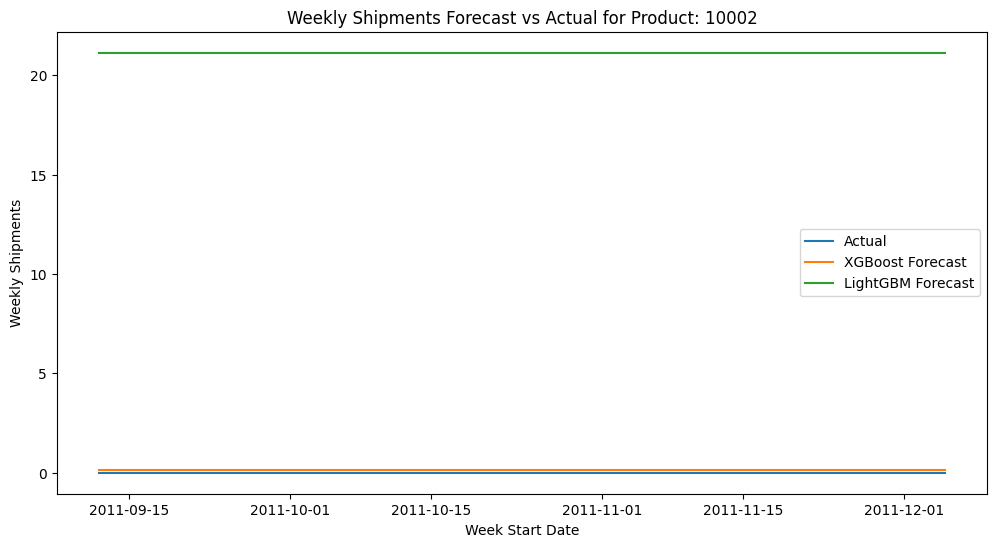

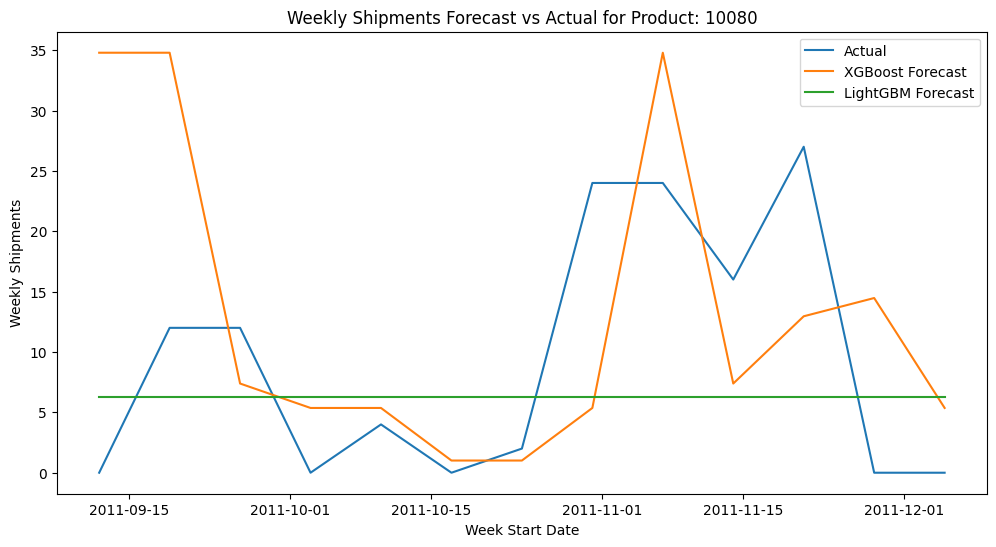

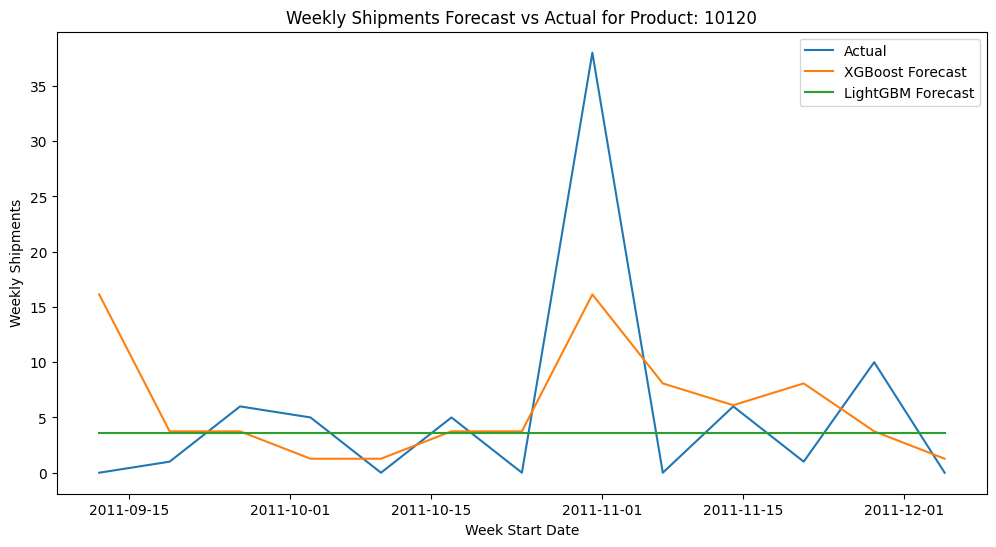

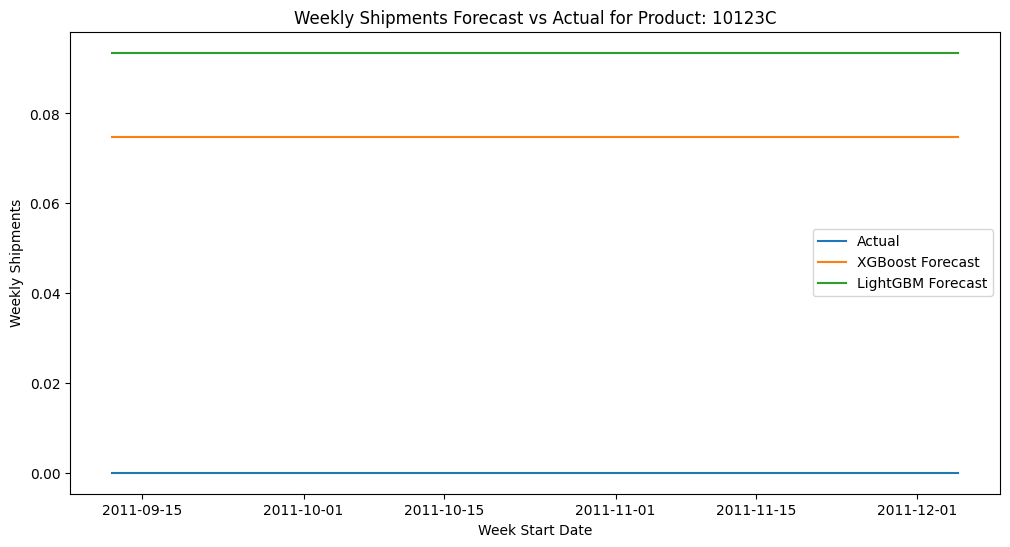

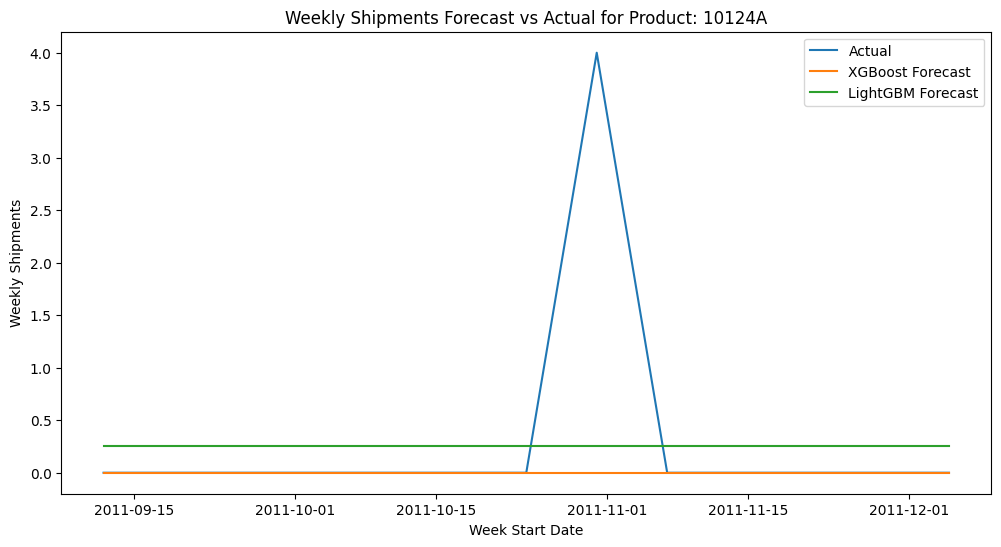

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure forecast columns exist in test_df before plotting
if 'xgb_forecast' not in test_df.columns:
    test_df['xgb_forecast'] = 0
if 'lgb_forecast' not in test_df.columns:
    test_df['lgb_forecast'] = 0

# Select a few product codes to visualize
products_to_visualize = test_df['StockCode'].unique()[:5]

for stock_code in products_to_visualize:
    product_test_data = test_df[test_df['StockCode'] == stock_code].copy()

    # Add forecasts to the product-specific test data
    if stock_code in xgboost_models:
        X_test = product_test_data[features]
        product_test_data['xgb_forecast'] = xgboost_models[stock_code].predict(X_test)

    if stock_code in lightgbm_models:
        X_test = product_test_data[features]
        product_test_data['lgb_forecast'] = lightgbm_models[stock_code].predict(X_test)

    plt.figure(figsize=(12, 6))
    sns.lineplot(x='WeekStartDate', y='WeeklyShipments', data=product_test_data, label='Actual')
    sns.lineplot(x='WeekStartDate', y='xgb_forecast', data=product_test_data, label='XGBoost Forecast')
    sns.lineplot(x='WeekStartDate', y='lgb_forecast', data=product_test_data, label='LightGBM Forecast')
    plt.title(f'Weekly Shipments Forecast vs Actual for Product: {stock_code}')
    plt.xlabel('Week Start Date')
    plt.ylabel('Weekly Shipments')
    plt.legend()
    plt.show()

## Model Comparison and Selection

Comparing the model performance and selecting the best model.

In [9]:
import numpy as np
from sklearn.metrics import mean_absolute_error # Import mean_absolute_error


# Calculate MAE for each model
test_df['xgb_mae'] = np.abs(test_df['WeeklyShipments'] - test_df['xgb_forecast'])
test_df['lgb_mae'] = np.abs(test_df['WeeklyShipments'] - test_df['lgb_forecast'])

# Calculate mean MAE for each model
mean_xgb_mae = test_df.groupby('StockCode')['xgb_mae'].mean().mean()
mean_lgb_mae = test_df.groupby('StockCode')['lgb_mae'].mean().mean()


if mean_xgb_mae <= mean_lgb_mae:
    best_model = "XGBoost"
    best_mae = mean_xgb_mae
else:
    best_model = "LightGBM"
    best_mae = mean_lgb_mae

print(f"The best performing model is {best_model} with a Mean MAE of {best_mae:.4f}")

The best performing model is XGBoost with a Mean MAE of 40.9626


## Model Evaluation

Calculating APE for each product and then calculating the mean of all product APEs for both models.

In [10]:
import numpy as np
from sklearn.metrics import mean_absolute_error # Import mean_absolute_error

# Calculate MAE for each model
test_df['xgb_mae'] = np.abs(test_df['WeeklyShipments'] - test_df['xgb_forecast'])
test_df['lgb_mae'] = np.abs(test_df['WeeklyShipments'] - test_df['lgb_forecast'])

# Calculate mean MAE for each model
mean_xgb_mae = test_df.groupby('StockCode')['xgb_mae'].mean().mean()
mean_lgb_mae = test_df.groupby('StockCode')['lgb_mae'].mean().mean()

print(f"Mean MAE for XGBoost: {mean_xgb_mae:.4f}")
print(f"Mean MAE for LightGBM: {mean_lgb_mae:.4f}")

Mean MAE for XGBoost: 40.9626
Mean MAE for LightGBM: 40.9626


## Forecasting

Forecasting sales for each product using the trained models.

In [11]:
test_df['xgb_forecast'] = 0
test_df['lgb_forecast'] = 0

for stock_code in unique_product_codes:
    product_test_df = test_df[test_df['StockCode'] == stock_code].copy()

    if stock_code in xgboost_models:
        X_test = product_test_df[features]
        test_df.loc[X_test.index, 'xgb_forecast'] = xgboost_models[stock_code].predict(X_test)

    if stock_code in lightgbm_models:
        X_test = product_test_df[features]
        test_df.loc[X_test.index, 'lgb_forecast'] = lightgbm_models[stock_code].predict(X_test)

display(test_df.head())

/tmp/ipython-input-2359423706.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.1419635 0.1419635 0.1419635 0.1419635 0.1419635 0.1419635 0.1419635
 0.1419635 0.1419635 0.1419635 0.1419635 0.1419635 0.1419635]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[X_test.index, 'xgb_forecast'] = xgboost_models[stock_code].predict(X_test)
/tmp/ipython-input-2359423706.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[21.13675935 21.13675935 21.13675935 21.13675935 21.13675935 21.13675935
 21.13675935 21.13675935 21.13675935 21.13675935 21.13675935 21.13675935
 21.13675935]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  test_df.loc[X_test.index, 'lgb_forecast'] = lightgbm_models[stock_code].predict(X_test)


,WeekStartDate,WeeklyShipments,StockCode,year,month,dayofweek,weekofyear,elapsed_weeks,lag_1_weeks,lag_4_weeks,lag_12_weeks,rolling_mean_4_weeks,rolling_sum_4_weeks,rolling_mean_12_weeks,rolling_sum_12_weeks,xgb_forecast,lgb_forecast,xgb_mae,lgb_mae
1715,2011-09-12,0,10002,2011,9,0,37,41,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.141963,21.136759,0,0
1716,2011-09-19,0,10002,2011,9,0,38,42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.141963,21.136759,0,0
1717,2011-09-26,0,10002,2011,9,0,39,43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.141963,21.136759,0,0
1718,2011-10-03,0,10002,2011,10,0,40,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.141963,21.136759,0,0
1719,2011-10-10,0,10002,2011,10,0,41,45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.141963,21.136759,0,0


### Using the best-performing model to predict future sales for the next 3 months using the entire 12 months of historical data as training data and saving the forecast into an excel file.

## Identifying the best model

Determining the best performing model based on the mean APE calculated in the previous steps.


In [12]:
if mean_xgb_mae <= mean_lgb_mae:
    best_model = "XGBoost"
    best_mae = mean_xgb_mae
else:
    best_model = "LightGBM"
    best_mae = mean_lgb_mae

print(f"The best performing model is {best_model} with a Mean MAE of {best_mae:.4f}")

The best performing model is XGBoost with a Mean MAE of 40.9626


## Preparing the full dataset

Combining the training and testing data to create a full 12-month dataset.


In [13]:
full_df = pd.concat([train_df, test_df])
display(full_df.head())
print(f"Full dataset shape: {full_df.shape}")

,WeekStartDate,WeeklyShipments,StockCode,year,month,dayofweek,weekofyear,elapsed_weeks,lag_1_weeks,lag_4_weeks,lag_12_weeks,rolling_mean_4_weeks,rolling_sum_4_weeks,rolling_mean_12_weeks,rolling_sum_12_weeks,xgb_forecast,lgb_forecast,xgb_mae,lgb_mae
1674,2010-11-29,70,10002,2010,11,0,48,0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1675,2010-12-06,138,10002,2010,12,0,49,1,70.0,0.0,0.0,0.00,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1676,2010-12-13,41,10002,2010,12,0,50,2,138.0,0.0,0.0,0.00,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1677,2010-12-20,2,10002,2010,12,0,51,3,41.0,0.0,0.0,62.75,251.0,0.0,0.0,NaN,NaN,NaN,NaN
1678,2010-12-27,0,10002,2010,12,0,52,4,2.0,70.0,0.0,45.25,181.0,0.0,0.0,NaN,NaN,NaN,NaN


Full dataset shape: (211788, 19)


## Retraining the best model

Retraining the best performing model (XGBoost) on the full 12-month dataset for each product.

In [ ]:
import xgboost as xgb
import numpy as np

retrained_xgboost_models = {}
features = ['year', 'month', 'dayofweek', 'weekofyear', 'elapsed_weeks',
            'lag_1_weeks', 'lag_4_weeks', 'lag_12_weeks',
            'rolling_mean_4_weeks', 'rolling_sum_4_weeks',
            'rolling_mean_12_weeks', 'rolling_sum_12_weeks']
target = 'WeeklyShipments'


for stock_code in unique_product_codes:
    product_full_df = full_df[full_df['StockCode'] == stock_code].copy()

    if not product_full_df.empty:
        X_full = product_full_df[features]
        y_full = product_full_df[target]

        # Use the best parameters found during the initial tuning
        if stock_code in xgboost_best_params:
            best_params = xgboost_best_params[stock_code]
        else:
            # Use default parameters or a predefined set if best params were not found
            best_params = {'n_estimators': 100, 'learning_rate': 0.1, 'max_depth': 3}


        try:
            # Train XGBoost model on the full dataset
            retrained_model = xgb.XGBRegressor(random_state=42, **best_params)
            retrained_model.fit(X_full, y_full)

            # Store the retrained model
            retrained_xgboost_models[stock_code] = retrained_model
            print(f"Retrained XGBoost model for {stock_code}")

        except Exception as e:
            print(f"Could not retrain XGBoost model for {stock_code}: {e}")

print(f"Retrained XGBoost models for {len(retrained_xgboost_models)} products.")

## Preparing future dates for forecasting

Creating a DataFrame with future dates for the next 3 months and generate the necessary features.

In [15]:
import numpy as np
import pandas as pd

# Determine the last date in the full dataset
last_date = full_df['WeekStartDate'].max()

# Create a date range for the next 3 months (weekly frequency)
future_dates = pd.date_range(start=last_date + pd.DateOffset(weeks=1), periods=12, freq='W-MON') # 3 months is approximately 12 weeks

# Create a DataFrame with future dates and all unique product codes
future_df = pd.DataFrame({'WeekStartDate': np.tile(future_dates.tolist(), len(unique_product_codes)),
                          'StockCode': np.repeat(unique_product_codes, len(future_dates))})

# Ensure WeekStartDate is datetime
future_df['WeekStartDate'] = pd.to_datetime(future_df['WeekStartDate'])

# Generate the same time-based features as used in training
future_df['year'] = future_df['WeekStartDate'].dt.year
future_df['month'] = future_df['WeekStartDate'].dt.month
future_df['dayofweek'] = future_df['WeekStartDate'].dt.dayofweek
future_df['weekofyear'] = future_df['WeekStartDate'].dt.isocalendar().week

# Calculate elapsed time from the overall minimum date
future_df['elapsed_weeks'] = (future_df['WeekStartDate'] - min_date).dt.days // 7


# Generate lag and rolling window features for future dates
# This requires combining historical data with future data for correct calculation
combined_df = pd.concat([full_df[['WeekStartDate', 'StockCode', 'WeeklyShipments']], future_df[['WeekStartDate', 'StockCode']]], ignore_index=True)
combined_df = combined_df.sort_values(by=['StockCode', 'WeekStartDate']).reset_index(drop=True)

for lag in [1, 4, 12]:
    combined_df[f'lag_{lag}_weeks'] = combined_df.groupby('StockCode')['WeeklyShipments'].shift(lag)

for window in [4, 12]:
    combined_df[f'rolling_mean_{window}_weeks'] = combined_df.groupby('StockCode')['WeeklyShipments'].rolling(window=window).mean().reset_index(level=0, drop=True)
    combined_df[f'rolling_sum_{window}_weeks'] = combined_df.groupby('StockCode')['WeeklyShipments'].rolling(window=window).sum().reset_index(level=0, drop=True)

# Select only the future dates with generated features
future_df_processed = combined_df[combined_df['WeekStartDate'].isin(future_dates)].copy()

# Fill any remaining NaNs which might occur at the beginning of the future period for rolling features
future_df_processed.fillna(0, inplace=True)


display(future_df_processed.head())
print(f"Future dataset shape: {future_df_processed.shape}")

,WeekStartDate,StockCode,WeeklyShipments,lag_1_weeks,lag_4_weeks,lag_12_weeks,rolling_mean_4_weeks,rolling_sum_4_weeks,rolling_mean_12_weeks,rolling_sum_12_weeks
54,2011-12-12,10002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55,2011-12-19,10002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
56,2011-12-26,10002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
57,2012-01-02,10002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58,2012-01-09,10002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Future dataset shape: (47064, 10)


## Generating future forecasts

Using the retrained best model to predict sales for the future dates.

In [16]:
import pandas as pd
import numpy as np # Import numpy

future_forecasts_list = []
features = ['year', 'month', 'dayofweek', 'weekofyear', 'elapsed_weeks',
            'lag_1_weeks', 'lag_4_weeks', 'lag_12_weeks',
            'rolling_mean_4_weeks', 'rolling_sum_4_weeks',
            'rolling_mean_12_weeks', 'rolling_sum_12_weeks'] # Ensure features match those used for training

# Merge future_df_processed with future_df to get all features
future_df_complete = future_df_processed.merge(future_df[['WeekStartDate', 'StockCode', 'year', 'month', 'dayofweek', 'weekofyear', 'elapsed_weeks']], on=['WeekStartDate', 'StockCode'], how='left')


for stock_code in unique_product_codes:
    product_future_df = future_df_complete[future_df_complete['StockCode'] == stock_code].copy()

    if not product_future_df.empty and stock_code in retrained_xgboost_models:
        X_future = product_future_df[features]
        retrained_model = retrained_xgboost_models[stock_code]

        try:
            # Generate forecasts
            future_forecast = retrained_model.predict(X_future)

            # Ensure forecasts are non-negative
            future_forecast = np.maximum(0, future_forecast)


            # Add forecasts to the product's future DataFrame
            product_future_df['forecasted_WeeklyShipments'] = future_forecast
            future_forecasts_list.append(product_future_df)

        except Exception as e:
            print(f"Could not generate future forecast for {stock_code}: {e}")


# Concatenate all product future forecasts into a single DataFrame
if future_forecasts_list:
    future_forecasts_df = pd.concat(future_forecasts_list, ignore_index=True)
    display(future_forecasts_df.head())
    print(f"Generated future forecasts for {len(future_forecasts_df['StockCode'].unique())} products.")
else:
    print("No future forecasts were generated.")
    future_forecasts_df = pd.DataFrame() # Create an empty DataFrame if no forecasts were generated

,WeekStartDate,StockCode,WeeklyShipments,lag_1_weeks,lag_4_weeks,lag_12_weeks,rolling_mean_4_weeks,rolling_sum_4_weeks,rolling_mean_12_weeks,rolling_sum_12_weeks,year,month,dayofweek,weekofyear,elapsed_weeks,forecasted_WeeklyShipments
0,2011-12-12,10002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2011,12,0,50,54,0.085662
1,2011-12-19,10002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2011,12,0,51,55,0.085662
2,2011-12-26,10002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2011,12,0,52,56,0.085662
3,2012-01-02,10002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2012,1,0,1,57,6.394754
4,2012-01-09,10002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2012,1,0,2,58,6.394754


Generated future forecasts for 3922 products.


## Saving the forecasts

Saving the future forecasts into an Excel file.

In [17]:
# Select relevant columns for the output file
output_df = future_forecasts_df[['WeekStartDate', 'StockCode', 'forecasted_WeeklyShipments']]

# Save the DataFrame to an Excel file
output_filename = 'future_sales_forecasts.xlsx'
output_df.to_excel(output_filename, index=False)

print(f"Future sales forecasts saved to '{output_filename}'")

Future sales forecasts saved to 'future_sales_forecasts.xlsx'
